In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [2]:
fusion = pd.read_csv("../dataset/processed/adaptive_fusion_dataset.csv")

fusion.head()

,Traffic_Score,Workload,Multiple_Deliveries,Peak,Festival,Rider_Experience,Ratings,Traffic_Workload,Demand_Index,Rider_Load,...,Experience,Delivery_Index,Weather_Impact,Experience_Index,Order_Hour,Pickup_Hour,Weekend,Month,Delivery_person_Age,Time_taken (min)
0,4,3.0,3.0,3,0,151.2,4.2,12.0,16,37.80,...,151.2,41.122328,41.122328,30.240000,21,22,1,2,36.0,46
1,3,1.0,1.0,2,0,98.7,4.7,3.0,9,49.35,...,98.7,18.726956,31.211593,24.675000,14,15,1,2,21.0,23
2,2,1.0,1.0,0,0,108.1,4.7,2.0,2,54.05,...,108.1,27.575720,82.727161,36.033333,17,17,0,3,23.0,21
3,1,0.0,0.0,1,0,146.2,4.3,0.0,2,146.20,...,146.2,2.930258,17.581547,73.100000,9,9,1,2,34.0,20
4,4,1.0,1.0,3,0,112.8,4.7,4.0,16,56.40,...,112.8,77.586473,77.586473,22.560000,19,20,0,2,24.0,41


In [3]:
q1 = fusion["Time_taken (min)"].quantile(0.50)
q2 = fusion["Time_taken (min)"].quantile(0.75)

print(q1, q2)

26.0 32.0


In [4]:
def delay_category(x):

    if x <= q1:
        return 0      # Low

    elif x <= q2:
        return 1      # Medium

    else:
        return 2      # High

fusion["Delay_Risk"] = fusion["Time_taken (min)"].apply(delay_category)

In [5]:
X = fusion.drop(columns=[
    "Time_taken (min)",
    "Delay_Risk"
])

y = fusion["Delay_Risk"]

In [6]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

In [7]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
delay_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            random_state=42
        )
    )
])

In [10]:
delay_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Traffic_Score', 'Workload',
                                                   'Multiple_Deliveries',
                                                   'Peak', 'Festival',
                                                   'Rider_Experience',
                                                   'Ratings',
                                                   'Traffic_Workload',
                                                   'Demand_Index', 'Rider_Load',
                                                   'Trip_Distance', 'Traffic',
                                                   'Vehicle',
                                                   'Vehicle_Condition',
                                                   'Restaurant_Lat'...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None, num_class=3,
                               num_parallel_tree=None, ...))])

In [11]:
pred = delay_model.predict(X_test)

prob = delay_model.predict_proba(X_test)

In [12]:
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average="weighted"))
print("Recall   :", recall_score(y_test, pred, average="weighted"))
print("F1 Score :", f1_score(y_test, pred, average="weighted"))

print("\nClassification Report\n")

print(classification_report(y_test, pred))

Accuracy : 0.7874491702384877
Precision: 0.7636784479743292
Recall   : 0.7874491702384877
F1 Score : 0.7675145957373664

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.93      0.87      4964
           1       0.54      0.32      0.40      1885
           2       0.84      0.86      0.85      2250

    accuracy                           0.79      9099
   macro avg       0.73      0.70      0.71      9099
weighted avg       0.76      0.79      0.77      9099



In [13]:
joblib.dump(
    delay_model,
    "../Modelv3/delay_risk_model.pkl"
)

['../Modelv3/delay_risk_model.pkl']

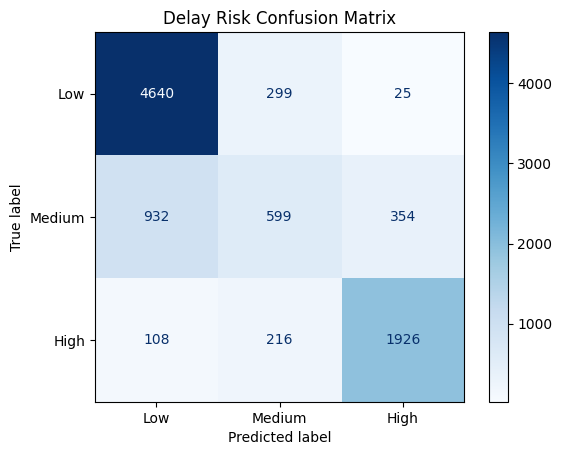

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=["Low", "Medium", "High"],
    cmap="Blues"
)

plt.title("Delay Risk Confusion Matrix")
plt.show()